# Text Analytics Coursework

### Customer Support Ticket EDA
This section explored the dataset to understand the nature of customer issues and inform preprocessing and modelling decisions. 
The analysis focuses on identifying common patterns in customer complaints and evaluating data quality. 

In [1]:
# Data Exploration Notebook : to understand customer issues 
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
nltk.download('stopwords', quiet=True)


True

In [2]:
# Load the data
df = pd.read_csv("customer_support_tickets.csv")

# Inspect data
print("\nFirst 5 rows of the dataset:")
display(df.head())
print(df.info())
print(df.describe())


First 5 rows of the dataset:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [3]:
# Exploratory Data Analysis (EDA)
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [4]:
# Hundle missing values
missing_descriptions = df['Ticket Description'].isnull().sum()
print(f"\nNumber of tickets with missing descriptions: {missing_descriptions}")


Number of tickets with missing descriptions: 0


The missing values were examined to assess data quality. 
The dataset contains missing values, which could affect analysis and ranking later.

In [5]:
# Check for duplication
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0



Ticket Length Statistics:
count    8469.000000
mean       46.467352
std         8.461730
min        21.000000
25%        43.000000
50%        49.000000
75%        52.000000
max        63.000000
Name: Ticket Length, dtype: float64


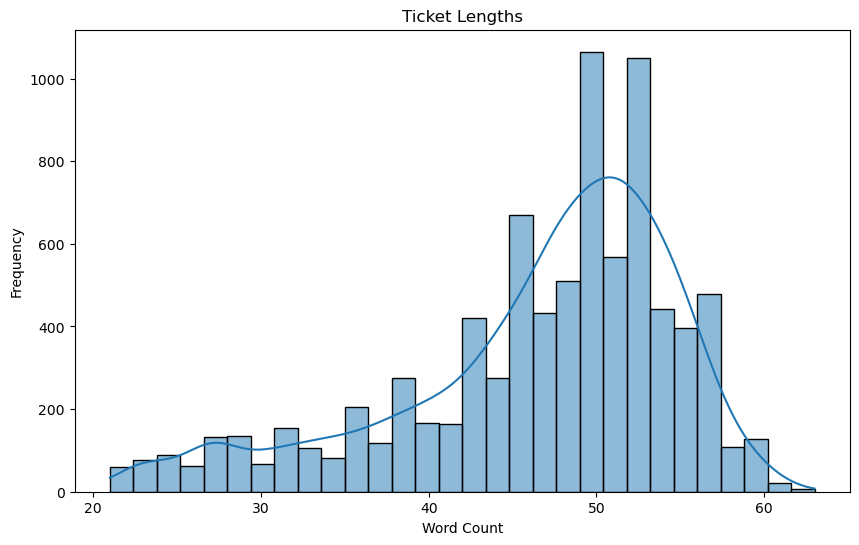

In [6]:
# Ticket Length analysis
df['Ticket Length'] = df['Ticket Description'].apply(lambda x: len(str(x).split()))
print("\nTicket Length Statistics:")
print(df['Ticket Length'].describe())

# Visualise it
plt.figure(figsize=(10, 6))
sns.histplot(df['Ticket Length'], bins=30, kde=True)
plt.title ('Ticket Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

## Ticket length distribution 
The distribution of ticket length was analysed to understand how detailed customer complaints are. 
The distribution shows that most customer support tickets contain a moderate number of words, suggesting that customers generally provide sufficiently detailed issues, which is useful for text analysis. 

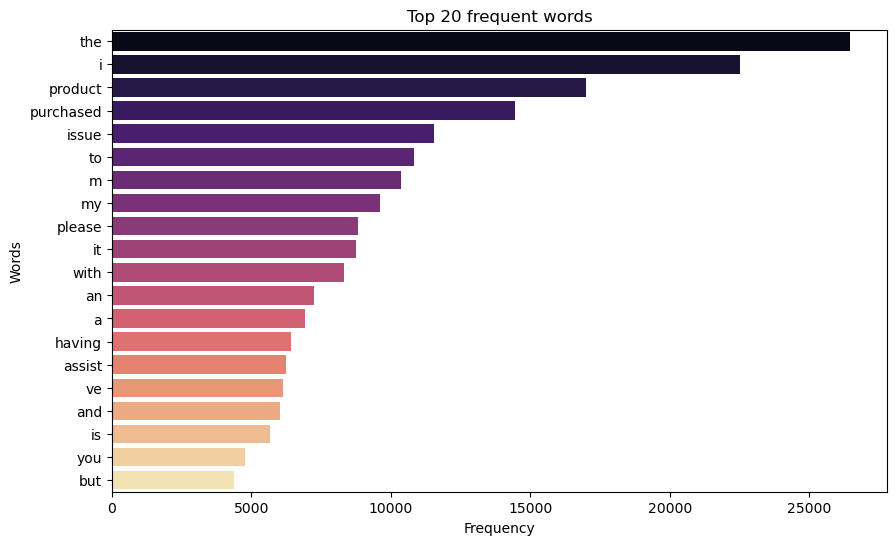

In [7]:
# Basic cleaning 
#convert to lowercase
# remove numbers, punctuation, and white spaces
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = text.strip()
    return text

#Apply Cleaning 
df["clean_text"] = df["Ticket Description"].apply(clean_text)

# plot top unigrams    
all_words = " ".join(df["clean_text"]).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 frequent words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


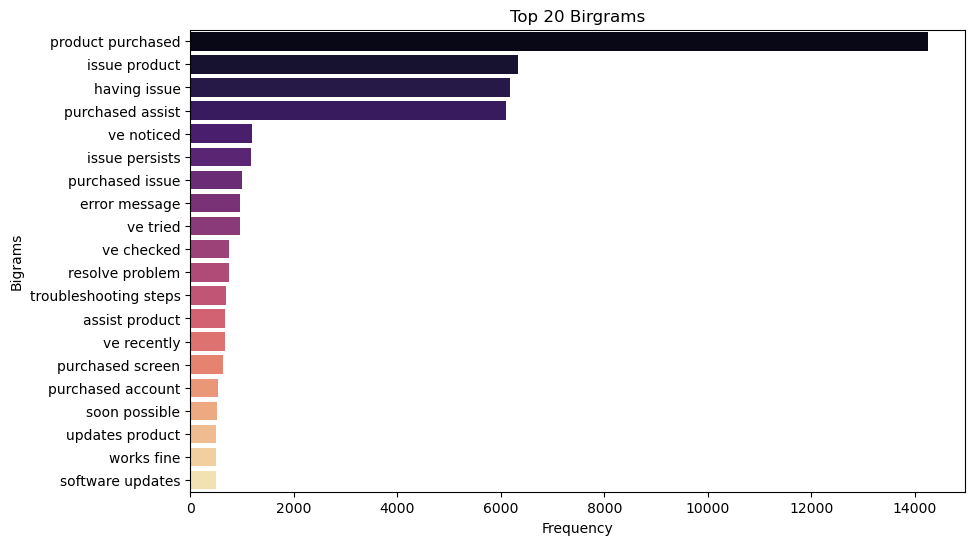

In [8]:
# Extract bigrams
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
x = vectorizer.fit_transform(df["clean_text"])

# Frequencies
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# combine and sort
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

# plot
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title("Top 20 Birgrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

## Most frequent words and phrases
Unigram analysis was performed to identify the most frequent words used by customers in the dataset.
in addition, bigram analysis was also conducted to capture common word pairs to provide more context to customer issues and revealing more specific patterns such as " product purchased", or " error message"

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


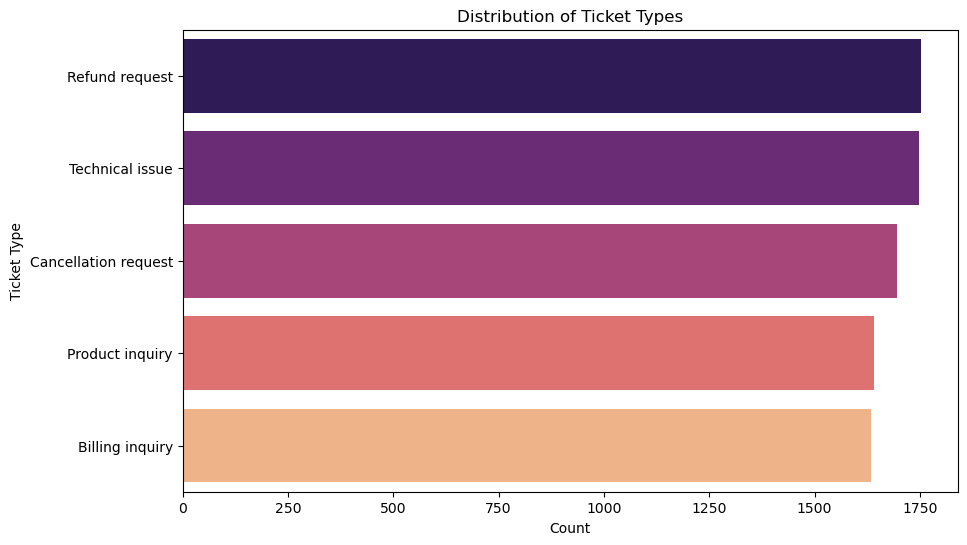

In [11]:
# Analyse ticket type
ticket_counts = df["Ticket Type"].value_counts()
print(ticket_counts)

#plot
plt.figure(figsize=(10,6))
sns.barplot(x=ticket_counts.values, y=ticket_counts.index, hue=ticket_counts.index, palette='magma')
plt.title("Distribution of Ticket Types")
plt.xlabel("Count")
plt.ylabel("Ticket Type")
plt.show()

### Distribution of ticket types
The distribution of ticket types was analysed to understand the most common categories of customer issues, which shows that some ticket types occur more frequently, indicating key areas where customers experiance issues.  